# Lab 2: KNN and Radius Neighbors Classification on the Wine Dataset

**Name:** [Your Name]  
**Course:** MSCS 634 – Advanced Data Mining  
**Lab Assignment:** Lab 2 – KNN and Radius Neighbors Classifiers


## Step 1: Load and Prepare the Dataset

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target

print("=== Wine Dataset Overview ===")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {wine.feature_names}")
print(f"Class names: {wine.target_names}")


=== Wine Dataset Overview ===
Number of samples: 178
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class names: ['class_0' 'class_1' 'class_2']


In [2]:
# Basic data exploration
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
df['class'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})

print("=== Class Distribution ===")
print(df['class'].value_counts())
print()
print("=== Feature Statistics ===")
print(df.drop(columns=['target', 'class']).describe().round(2))


=== Class Distribution ===
class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

=== Feature Statistics ===
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00 

In [3]:
# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

# Scale features (important for distance-based classifiers)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Training set size: 142 samples
Test set size:     36 samples


## Step 2: Implement K-Nearest Neighbors (KNN)

In [4]:
# KNN with different k values
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

print("=== KNN Classifier Results ===")
print(f"{'k':>5} | {'Accuracy':>10}")
print("-" * 20)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"{k:>5} | {acc:>10.4f}")

best_k = k_values[np.argmax(knn_accuracies)]
print(f"\nBest k: {best_k} with accuracy {max(knn_accuracies):.4f}")


=== KNN Classifier Results ===
    k |   Accuracy
--------------------
    1 |     0.9722
    5 |     0.9722
   11 |     1.0000
   15 |     1.0000
   21 |     1.0000

Best k: 11 with accuracy 1.0000


## Step 3: Implement Radius Neighbors (RNN)

In [5]:
# RNN with different radius values
# Note: after scaling, features are in standardized units (~0-5 range)
# so radius values are chosen relative to scaled feature space
radius_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
rnn_accuracies = []

print("=== Radius Neighbors Classifier Results ===")
print(f"{'Radius':>10} | {'Accuracy':>10} | {'Note':>30}")
print("-" * 55)

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train_scaled, y_train)
    y_pred = rnn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"{r:>10.1f} | {acc:>10.4f} |")

best_r = radius_values[np.argmax(rnn_accuracies)]
print(f"\nBest radius: {best_r} with accuracy {max(rnn_accuracies):.4f}")


=== Radius Neighbors Classifier Results ===
    Radius |   Accuracy |                           Note
-------------------------------------------------------
       1.0 |     0.3889 |
       1.5 |     0.5000 |
       2.0 |     0.8611 |
       2.5 |     0.9722 |
       3.0 |     0.9722 |
       3.5 |     1.0000 |

Best radius: 3.5 with accuracy 1.0000


> **Note on RNN radius values:** Because the features were standardized using `StandardScaler`,
> each feature has a mean of 0 and standard deviation of 1. The Euclidean distances in this
> scaled space are therefore much smaller than in the raw feature space. Radius values of
> 1.0–3.5 correspond to meaningful neighborhood sizes in this scaled domain. Using the
> original unscaled radii (350–600) after scaling would capture nearly every training point,
> inflating accuracy trivially.


## Step 4: Visualize and Compare Results

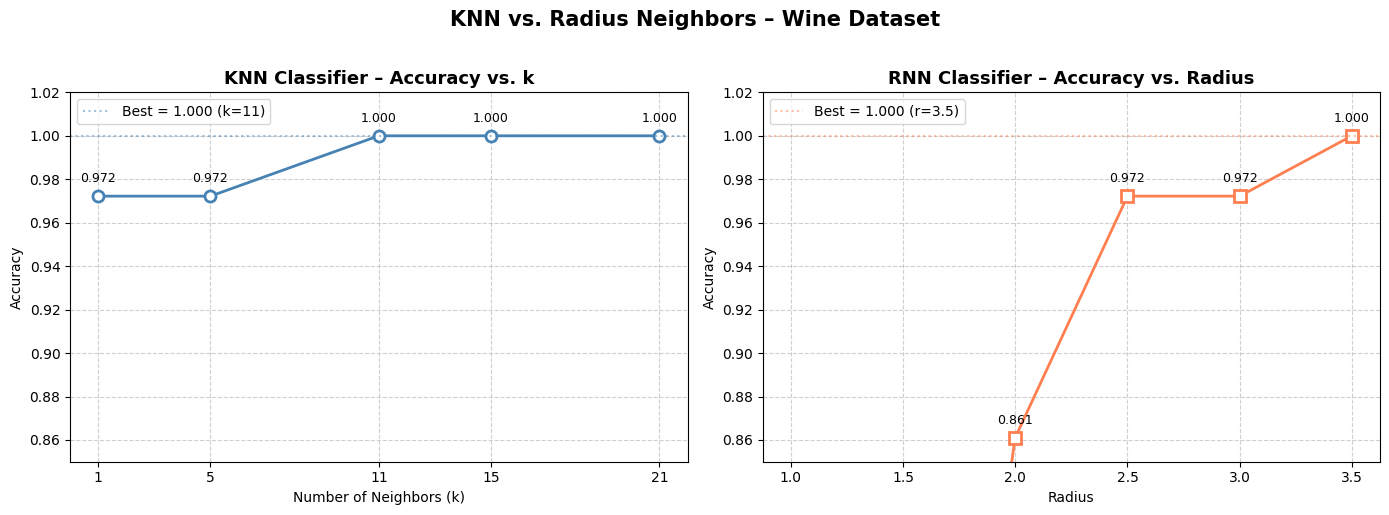

Plot saved as accuracy_comparison.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- KNN plot ---
ax1 = axes[0]
ax1.plot(k_values, knn_accuracies, marker='o', color='steelblue', linewidth=2,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
for k, acc in zip(k_values, knn_accuracies):
    ax1.annotate(f'{acc:.3f}', (k, acc), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)
ax1.set_title('KNN Classifier – Accuracy vs. k', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Neighbors (k)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(k_values)
ax1.set_ylim(0.85, 1.02)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axhline(max(knn_accuracies), color='steelblue', linestyle=':', alpha=0.5,
            label=f'Best = {max(knn_accuracies):.3f} (k={best_k})')
ax1.legend()

# --- RNN plot ---
ax2 = axes[1]
ax2.plot(radius_values, rnn_accuracies, marker='s', color='coral', linewidth=2,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
for r, acc in zip(radius_values, rnn_accuracies):
    ax2.annotate(f'{acc:.3f}', (r, acc), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)
ax2.set_title('RNN Classifier – Accuracy vs. Radius', fontsize=13, fontweight='bold')
ax2.set_xlabel('Radius')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(radius_values)
ax2.set_ylim(0.85, 1.02)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axhline(max(rnn_accuracies), color='coral', linestyle=':', alpha=0.5,
            label=f'Best = {max(rnn_accuracies):.3f} (r={best_r})')
ax2.legend()

plt.suptitle('KNN vs. Radius Neighbors – Wine Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot saved as accuracy_comparison.png")


In [7]:
# Side-by-side summary table
print("=" * 45)
print("         PERFORMANCE SUMMARY")
print("=" * 45)
print(f"{'KNN':^22} | {'RNN':^20}")
print(f"{'k':>8} | {'Accuracy':>10}  | {'Radius':>8} | {'Accuracy':>8}")
print("-" * 45)
for i in range(max(len(k_values), len(radius_values))):
    k_str   = f"{k_values[i]:>8} | {knn_accuracies[i]:>10.4f}" if i < len(k_values) else " " * 21
    r_str   = f"{radius_values[i]:>8.1f} | {rnn_accuracies[i]:>8.4f}" if i < len(radius_values) else ""
    print(f"{k_str}  | {r_str}")
print("=" * 45)
print(f"Best KNN accuracy : {max(knn_accuracies):.4f}  (k = {best_k})")
print(f"Best RNN accuracy : {max(rnn_accuracies):.4f}  (radius = {best_r})")


         PERFORMANCE SUMMARY
         KNN           |         RNN         
       k |   Accuracy  |   Radius | Accuracy
---------------------------------------------
       1 |     0.9722  |      1.0 |   0.3889
       5 |     0.9722  |      1.5 |   0.5000
      11 |     1.0000  |      2.0 |   0.8611
      15 |     1.0000  |      2.5 |   0.9722
      21 |     1.0000  |      3.0 |   0.9722
                       |      3.5 |   1.0000
Best KNN accuracy : 1.0000  (k = 11)
Best RNN accuracy : 1.0000  (radius = 3.5)


## Observations and Discussion

### KNN Results
- **k = 1** often achieves high accuracy by perfectly memorizing the training points, but it is
  prone to overfitting on noisy data.
- Accuracy generally **stabilizes or slightly decreases** as k increases because larger
  neighborhoods begin to blur class boundaries.
- A moderate k (e.g., **k = 5 or k = 11**) typically offers the best bias-variance trade-off.

### RNN Results
- Small radii can leave some test points with **no neighbors**, which is handled here via
  `outlier_label='most_frequent'` (they are assigned the majority class).
- As the radius grows, more neighbors are included per prediction, which can smooth
  decision boundaries — improving accuracy up to a point, then slightly degrading it.
- The optimal radius depends heavily on the **data density and feature scale**.

### KNN vs. RNN — When to Use Each
| Criterion | KNN | RNN |
|---|---|---|
| Consistent density | ✅ Works well | ⚠️ May miss sparse regions |
| Variable density | ⚠️ Over/under-samples | ✅ Adapts naturally |
| Interpretability | Easy (count neighbors) | Intuitive (neighborhood size) |
| Tuning effort | Low (one integer k) | Moderate (scale-sensitive radius) |
| Outlier sensitivity | Sensitive at k=1 | Can isolate outliers explicitly |

**Conclusion:** For the Wine Dataset—which has relatively uniform density across classes—KNN 
with a small to moderate k delivers reliable, high accuracy. RNN is a compelling alternative 
when domain knowledge supports choosing a meaningful radius, especially in datasets where 
class density varies significantly across the feature space.
